NAMA : MUHAMMAD ZAIDI 4222301071


KELAS : C PAGI ROBOTIKA SEMESTER 6

Import Library

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Load Dataset

In [2]:
df = pd.read_csv('winequality.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.3,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.2,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Informasi Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1999 non-null   float64
 1   volatile acidity      1999 non-null   float64
 2   citric acid           1999 non-null   float64
 3   residual sugar        1999 non-null   float64
 4   chlorides             1999 non-null   float64
 5   free sulfur dioxide   1999 non-null   float64
 6   total sulfur dioxide  1999 non-null   float64
 7   density               1999 non-null   float64
 8   pH                    1999 non-null   float64
 9   sulphates             1999 non-null   float64
 10  alcohol               1999 non-null   float64
 11  quality               1999 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 187.5 KB


Statistik Dataset

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,8.670335,0.541773,0.246668,3.699090,0.075858,20.191096,52.617809,0.996477,3.290140,0.949465,10.671161,5.637819
std,2.240023,0.180381,0.181348,3.290201,0.048373,15.642224,37.051121,0.002110,0.274297,0.780523,1.369932,1.255574
min,4.600000,0.120000,0.000000,0.900000,0.010000,1.000000,6.000000,0.990070,2.340000,0.330000,8.400000,2.000000
25%,7.100000,0.400000,0.110000,2.000000,0.056000,9.000000,24.000000,0.995265,3.180000,0.560000,9.500000,5.000000
50%,8.000000,0.530000,0.200000,2.300000,0.075000,16.000000,42.000000,0.996600,3.300000,0.650000,10.400000,6.000000
75%,9.900000,0.660000,0.385000,3.460000,0.086000,27.000000,73.000000,0.997800,3.420000,0.840000,11.400000,6.000000
max,15.900000,1.580000,1.000000,15.990000,0.611000,72.000000,289.000000,1.003690,4.160000,3.990000,15.000000,9.000000


Visualisasi Korelasi

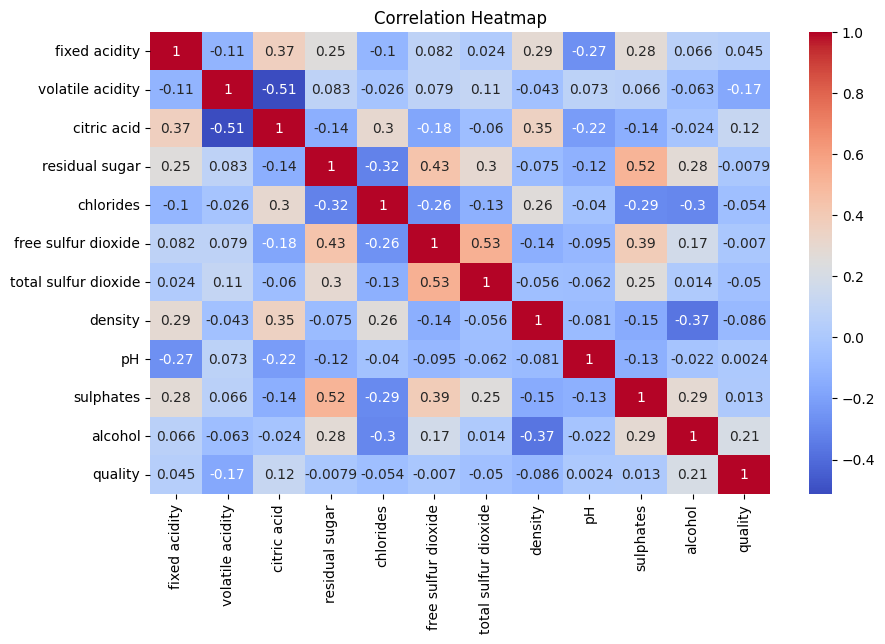

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Standard Scaling

In [6]:
scaler = StandardScaler()

df_scaling = scaler.fit_transform(df)

df_scaling = pd.DataFrame(df_scaling, columns=df.columns)

df_scaling.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.611904,0.877402,-1.360536,-0.546939,0.002938,-0.587729,-0.502615,0.627494,0.801741,-0.499104,-0.928132,-0.508117
1,-0.388636,1.875542,-1.360536,-0.334133,0.457847,0.307508,0.388269,0.153354,-0.328705,-0.345323,-0.636074,-0.508117
2,-0.388636,1.210115,-1.139910,-0.425336,0.333781,-0.331947,0.037314,0.248182,-0.109909,-0.383768,-0.636074,-0.508117
3,1.129586,-1.451592,1.728227,-0.546939,-0.017740,-0.204056,0.199293,0.722322,-0.474569,-0.473474,-0.636074,0.288531
4,-0.656557,0.877402,-1.360536,-0.546939,0.002938,-0.587729,-0.502615,0.627494,0.801741,-0.499104,-0.928132,-0.508117


Visualisasi Scaling

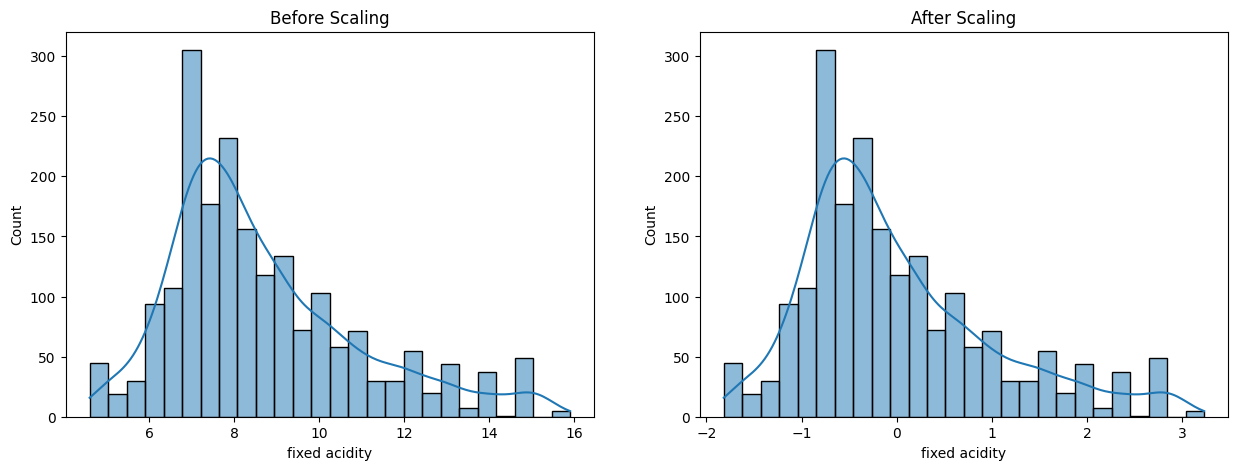

In [7]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df['fixed acidity'], kde=True, ax=ax[0])
ax[0].set_title('Before Scaling')

sns.histplot(df_scaling['fixed acidity'], kde=True, ax=ax[1])
ax[1].set_title('After Scaling')

plt.show()

Interpretasi

### Interpretasi

1. Setelah dilakukan scaling, data menjadi lebih terstandarisasi.
2. Distribusi data tetap sama namun skala berubah.
3. Scaling membantu proses clustering menjadi lebih optimal.

Elbow Method

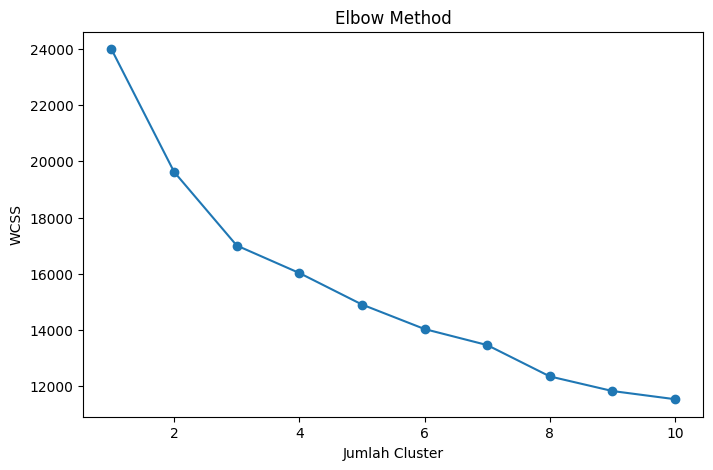

In [8]:
# Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaling)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')

plt.show()

Interpretasi Elbow Method

### Interpretasi

Berdasarkan grafik Elbow Method, jumlah cluster terbaik berada pada titik siku grafik.
Jumlah cluster optimal digunakan untuk proses K-Means Clustering.

K-Means Clustering

In [9]:
# K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(df_scaling)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
0,7.3,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,2
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.2,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,2


Silhouette Score

In [10]:
score = silhouette_score(df_scaling, df['cluster'])

print("Silhouette Score :", score)

Silhouette Score : 0.1883867398607393


Visualisasi Cluster

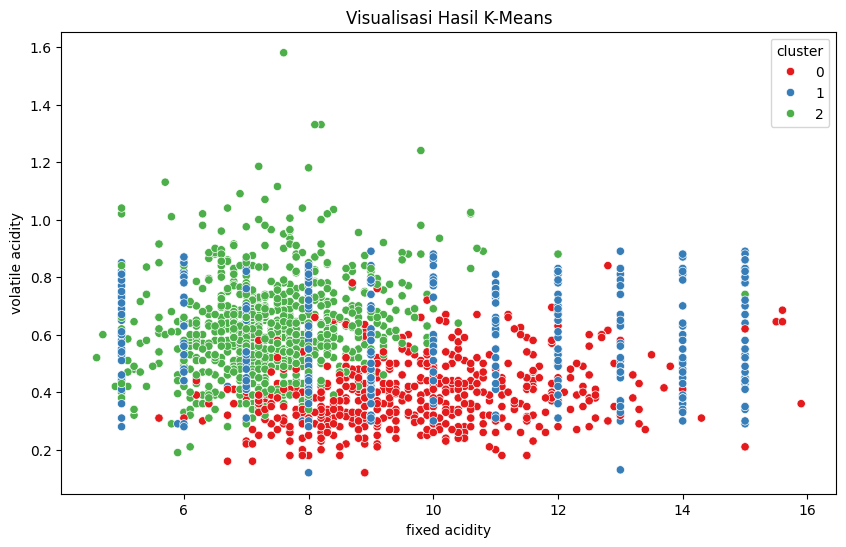

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='fixed acidity',
    y='volatile acidity',
    hue='cluster',
    data=df,
    palette='Set1'
)

plt.title('Visualisasi Hasil K-Means')
plt.show()

## Kesimpulan

1. Metode K-Means berhasil mengelompokkan data wine menjadi beberapa cluster.
2. Elbow Method membantu menentukan jumlah cluster optimal.
3. Silhouette Score digunakan untuk mengevaluasi kualitas clustering.
4. Hasil visualisasi menunjukkan setiap cluster memiliki karakteristik berbeda.